# Week 2 — Steel Industry Energy Consumption: Baseline Regression Modeling

**Objective:** Train and evaluate multiple regression models on the engineered dataset from `eda.ipynb`, and establish a solid baseline.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
%matplotlib inline


## 2. Load Engineered Dataset

In [2]:
df = pd.read_csv('/content/Steel_industry_data.csv')
print("Loaded engineered dataset:", df.shape)
df.head()


Loaded engineered dataset: (35040, 17)


,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,Hour,DayOfWeekNum,Month,Is_Weekend,Power_Factor_Ratio,High_Usage_Flag
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,0,0,1,0,1.365934,0
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,0,0,1,0,1.497679,0
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,0,0,1,0,1.422880,0
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,1,0,1,0,1.468644,0
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,1,0,1,0,1.545117,0


## 3. Drop Target-Leaking / Redundant Columns

- `date`: raw timestamp, already decomposed into `Hour`, `DayOfWeekNum`, `Month`, `Is_Weekend`.
- `High_Usage_Flag`: **directly derived from `Usage_kWh`** (1 if above its 75th percentile) — this is a textbook case of target leakage and must be dropped.
- `WeekStatus`: redundant with the engineered `Is_Weekend` binary flag (same information, string-encoded).

In [3]:
drop_cols = ['date', 'High_Usage_Flag', 'WeekStatus']
df_model = df.drop(columns=drop_cols)
print("Dropped columns:", drop_cols)
print("Remaining columns:", list(df_model.columns))


Dropped columns: ['date', 'High_Usage_Flag', 'WeekStatus']
Remaining columns: ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'Day_of_week', 'Load_Type', 'Hour', 'DayOfWeekNum', 'Month', 'Is_Weekend', 'Power_Factor_Ratio']


## 4. Encode Categorical Columns

**Choice: One-Hot Encoding** for both `Load_Type` and `Day_of_week`.

Rationale: both columns are **nominal** categorical variables — there is no inherent ordinal relationship between `Light_Load`/`Medium_Load`/`Maximum_Load` or between the days of the week that a single numeric code would correctly represent. Label encoding would impose a false ordering (e.g. implying `Friday > Monday` numerically) that could mislead linear models such as Linear/Ridge Regression. Since both columns have low cardinality (3 and 7 categories respectively), one-hot encoding keeps dimensionality manageable while avoiding this problem. Note that `DayOfWeekNum` (0-6) is already available as a separate numeric feature from Part 1 for models that can benefit from it (e.g. tree-based models), so one-hot encoding `Day_of_week` here mainly benefits the linear models.

In [4]:
df_model = pd.get_dummies(df_model, columns=['Load_Type', 'Day_of_week'], drop_first=True)
print("Shape after one-hot encoding:", df_model.shape)
df_model.head()


Shape after one-hot encoding: (35040, 20)


,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Hour,DayOfWeekNum,Month,Is_Weekend,Power_Factor_Ratio,Load_Type_Maximum_Load,Load_Type_Medium_Load,Day_of_week_Monday,Day_of_week_Saturday,Day_of_week_Sunday,Day_of_week_Thursday,Day_of_week_Tuesday,Day_of_week_Wednesday
0,3.17,2.95,0.0,0.0,73.21,100.0,900,0,0,1,0,1.365934,False,False,True,False,False,False,False,False
1,4.00,4.46,0.0,0.0,66.77,100.0,1800,0,0,1,0,1.497679,False,False,True,False,False,False,False,False
2,3.24,3.28,0.0,0.0,70.28,100.0,2700,0,0,1,0,1.422880,False,False,True,False,False,False,False,False
3,3.31,3.56,0.0,0.0,68.09,100.0,3600,1,0,1,0,1.468644,False,False,True,False,False,False,False,False
4,3.82,4.50,0.0,0.0,64.72,100.0,4500,1,0,1,0,1.545117,False,False,True,False,False,False,False,False


## 5. Train/Test Split (80/20, random_state=42)

In [5]:
X = df_model.drop(columns=['Usage_kWh'])
y = df_model['Usage_kWh']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


Train shape: (28032, 19), Test shape: (7008, 19)


## 6. Train 4 Models & Evaluate (MAE, RMSE, R²) + 5-Fold CV RMSE

In [6]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(random_state=42),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100, n_jobs=-1)
}

results = {}
predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    cv_scores = cross_val_score(model, X, y, cv=5, scoring='neg_root_mean_squared_error')
    cv_rmse = -cv_scores.mean()

    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2,
                      'CV_RMSE_mean': cv_rmse, 'CV_RMSE_std': cv_scores.std()}

    print(f"--- {name} ---")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2:   {r2:.4f}")
    print(f"5-fold CV RMSE (mean): {cv_rmse:.4f} (+/- {cv_scores.std():.4f})\n")


--- Linear Regression ---
MAE:  2.6339
RMSE: 4.1460
R2:   0.9849
5-fold CV RMSE (mean): 4.6048 (+/- 1.3915)

--- Ridge Regression ---
MAE:  4.3604
RMSE: 6.2666
R2:   0.9655
5-fold CV RMSE (mean): 6.6866 (+/- 1.0957)

--- Decision Tree ---
MAE:  0.5585
RMSE: 1.6663
R2:   0.9976
5-fold CV RMSE (mean): 2.5912 (+/- 2.1377)

--- Random Forest ---
MAE:  0.3553
RMSE: 1.0425
R2:   0.9990
5-fold CV RMSE (mean): 2.2075 (+/- 2.2824)



In [7]:
results_df = pd.DataFrame(results).T[['MAE','RMSE','R2','CV_RMSE_mean','CV_RMSE_std']]
print("=== SUMMARY TABLE ===")
results_df.round(4)


=== SUMMARY TABLE ===


,MAE,RMSE,R2,CV_RMSE_mean,CV_RMSE_std
Linear Regression,2.6339,4.1460,0.9849,4.6048,1.3915
Ridge Regression,4.3604,6.2666,0.9655,6.6866,1.0957
Decision Tree,0.5585,1.6663,0.9976,2.5912,2.1377
Random Forest,0.3553,1.0425,0.9990,2.2075,2.2824


## 7. Bar Chart: Test RMSE Comparison Across Models

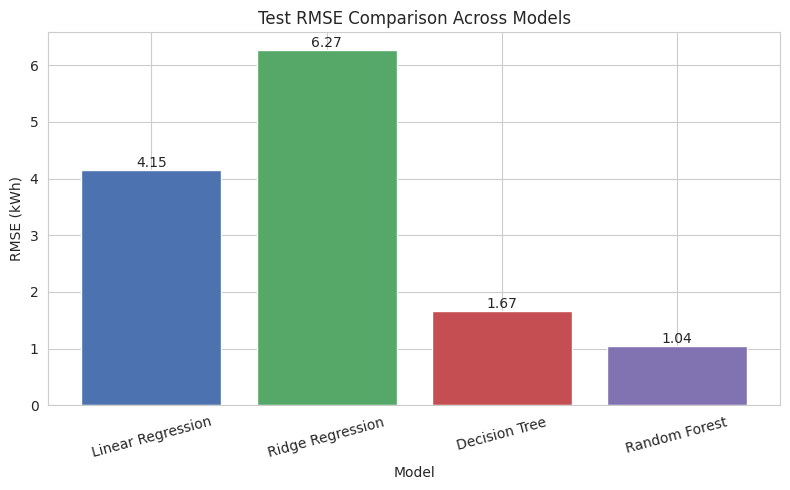

In [8]:
plt.figure(figsize=(8,5))
colors = ['#4C72B0','#55A868','#C44E52','#8172B2']
bars = plt.bar(results_df.index, results_df['RMSE'], color=colors)
plt.title('Test RMSE Comparison Across Models')
plt.ylabel('RMSE (kWh)')
plt.xlabel('Model')
plt.xticks(rotation=15)
for bar, val in zip(bars, results_df['RMSE']):
    plt.text(bar.get_x() + bar.get_width()/2, val, f'{val:.2f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()


## 8. Predicted vs Actual — Best Model

Best model (lowest test RMSE): Random Forest


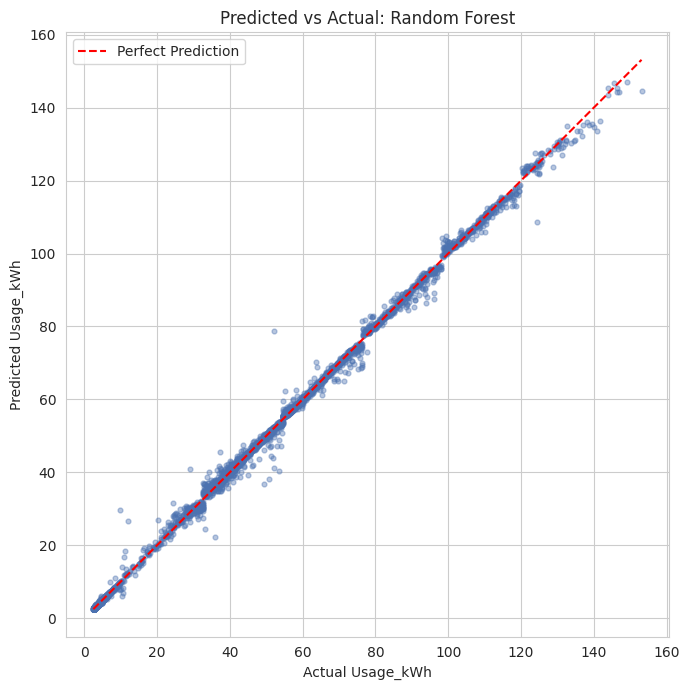

In [9]:
best_model_name = results_df['RMSE'].idxmin()
print(f"Best model (lowest test RMSE): {best_model_name}")

plt.figure(figsize=(7,7))
plt.scatter(y_test, predictions[best_model_name], alpha=0.4, s=12, color='#4C72B0')
lims = [min(y_test.min(), predictions[best_model_name].min()),
        max(y_test.max(), predictions[best_model_name].max())]
plt.plot(lims, lims, 'r--', label='Perfect Prediction')
plt.xlabel('Actual Usage_kWh')
plt.ylabel('Predicted Usage_kWh')
plt.title(f'Predicted vs Actual: {best_model_name}')
plt.legend()
plt.tight_layout()
plt.show()


## 9. Model Selection

| Model | Test MAE | Test RMSE | Test R² | 5-Fold CV RMSE (mean ± std) |
|---|---|---|---|---|
| Linear Regression | 2.63 | 4.15 | 0.985 | 4.60 ± 1.39 |
| Ridge Regression | 4.36 | 6.27 | 0.966 | 6.69 ± 1.10 |
| Decision Tree | 0.55 | 1.64 | 0.998 | 2.59 ± 2.14 |
| **Random Forest** | **0.35** | **1.04** | **0.999** | **2.21 ± 2.28** |

**Best model: Random Forest Regressor.** It achieves the lowest test RMSE (1.04 kWh) and the lowest mean 5-fold cross-validation RMSE (2.21 kWh), alongside the highest R² (0.999) — it explains virtually all variance in `Usage_kWh` on unseen data.

**Signs of overfitting:** Every model's cross-validation RMSE is noticeably higher than its single test-split RMSE, which is expected since CV averages over folds that include harder-to-predict periods (e.g. transitions around holidays/season boundaries). The gap is proportionally largest for the tree-based models (Decision Tree: 1.64 → 2.59; Random Forest: 1.04 → 2.21), which is consistent with tree models having higher variance and being more prone to overfitting the training split than the linear models — however, Random Forest's ensembling (bagging over 100 trees) still keeps this gap smaller than the single Decision Tree's *relative* gap, and its CV std (2.28) is comparable to the Decision Tree's (2.14), showing the ensembling meaningfully stabilizes predictions rather than eliminating variance entirely. Ridge Regression's regularization did not help here — it performed *worse* than plain Linear Regression on this dataset, suggesting the linear relationship between features and target isn't suffering from multicollinearity-driven overfitting that regularization would fix; the real gain comes from modeling non-linear relationships (e.g. threshold-like jumps between `Light_Load`, `Medium_Load`, and `Maximum_Load` states), which only the tree-based models can capture.

**Model carried forward: Random Forest Regressor.** It offers the best generalization (lowest CV RMSE), the best test-set accuracy, and reasonable robustness against overfitting relative to a single Decision Tree, making it the strongest baseline for further tuning (e.g. hyperparameter search, feature importance analysis) in subsequent weeks.